In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = False

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'enhancer_encode'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: enhancer_encode
  Filters: ["(pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)", "pl.col('pangolin_score') < 0.2", "pl.col('encode_enhancer') == True"]
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [3]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

# olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = pl.scan_parquet(new_anno_local)
# rna_cols = [c for c in new_anno_df.collect_schema().names() if c.startswith('RNA:')]
# 89 GTEx tissue tracks:
gtex_cols = ['RNA:adipose_tissue_7522', 'RNA:adipose_tissue_7523', 'RNA:adipose_tissue_7524', 'RNA:adrenal_gland_7525', 'RNA:adrenal_gland_7526', 'RNA:adrenal_gland_7527', 'RNA:bladder_7528', 'RNA:bladder_7529', 'RNA:bladder_7530', 'RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533', 'RNA:blood_vessel_7534', 'RNA:blood_vessel_7535', 'RNA:blood_vessel_7536', 'RNA:bone_marrow_7537', 'RNA:bone_marrow_7538', 'RNA:brain_7539', 'RNA:brain_7540', 'RNA:brain_7541', 'RNA:breast_7542', 'RNA:breast_7543', 'RNA:breast_7544', 'RNA:cervix_uteri_7545', 'RNA:cervix_uteri_7546', 'RNA:cervix_uteri_7547', 'RNA:colon_7548', 'RNA:colon_7549', 'RNA:colon_7550', 'RNA:esophagus_7551', 'RNA:esophagus_7552', 'RNA:esophagus_7553', 'RNA:fallopian_tube_7554', 'RNA:fallopian_tube_7555', 'RNA:fallopian_tube_7556', 'RNA:heart_7557', 'RNA:heart_7558', 'RNA:heart_7559', 'RNA:kidney_7560', 'RNA:kidney_7561', 'RNA:kidney_7562', 'RNA:liver_7563', 'RNA:liver_7564', 'RNA:liver_7565', 'RNA:lung_7566', 'RNA:lung_7567', 'RNA:lung_7568', 'RNA:muscle_7569', 'RNA:muscle_7570', 'RNA:muscle_7571', 'RNA:nerve_7572', 'RNA:nerve_7573', 'RNA:ovary_7574', 'RNA:ovary_7575', 'RNA:ovary_7576', 'RNA:pancreas_7577', 'RNA:pancreas_7578', 'RNA:pancreas_7579', 'RNA:pituitary_7580', 'RNA:pituitary_7581', 'RNA:pituitary_7582', 'RNA:prostate_7583', 'RNA:prostate_7584', 'RNA:prostate_7585', 'RNA:salivary_gland_7586', 'RNA:salivary_gland_7587', 'RNA:salivary_gland_7588', 'RNA:skin_7589', 'RNA:skin_7590', 'RNA:skin_7591', 'RNA:small_intestine_7592', 'RNA:small_intestine_7593', 'RNA:small_intestine_7594', 'RNA:spleen_7595', 'RNA:spleen_7596', 'RNA:spleen_7597', 'RNA:stomach_7598', 'RNA:stomach_7599', 'RNA:stomach_7600', 'RNA:testis_7601', 'RNA:testis_7602', 'RNA:thyroid_7603', 'RNA:thyroid_7604', 'RNA:thyroid_7605', 'RNA:uterus_7606', 'RNA:uterus_7607', 'RNA:vagina_7608', 'RNA:vagina_7609', 'RNA:vagina_7610']

new_anno_df = (
    new_anno_df
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_gtex_min = pl.min_horizontal(gtex_cols),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_gtex_min'] + gtex_cols)
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_89467/2268322955.py:20: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_gtex_min,RNA:adipose_tissue_7522,RNA:adipose_tissue_7523,RNA:adipose_tissue_7524,RNA:adrenal_gland_7525,RNA:adrenal_gland_7526,RNA:adrenal_gland_7527,RNA:bladder_7528,RNA:bladder_7529,RNA:bladder_7530,RNA:blood_7531,RNA:blood_7532,RNA:blood_7533,RNA:blood_vessel_7534,RNA:blood_vessel_7535,RNA:blood_vessel_7536,RNA:bone_marrow_7537,RNA:bone_marrow_7538,RNA:brain_7539,RNA:brain_7540,RNA:brain_7541,RNA:breast_7542,RNA:breast_7543,RNA:breast_7544,RNA:cervix_uteri_7545,RNA:cervix_uteri_7546,RNA:cervix_uteri_7547,RNA:colon_7548,RNA:colon_7549,RNA:colon_7550,RNA:esophagus_7551,RNA:esophagus_7552,RNA:esophagus_7553,RNA:fallopian_tube_7554,…,RNA:ovary_7574,RNA:ovary_7575,RNA:ovary_7576,RNA:pancreas_7577,RNA:pancreas_7578,RNA:pancreas_7579,RNA:pituitary_7580,RNA:pituitary_7581,RNA:pituitary_7582,RNA:prostate_7583,RNA:prostate_7584,RNA:prostate_7585,RNA:salivary_gland_7586,RNA:salivary_gland_7587,RNA:salivary_gland_7588,RNA:skin_7589,RNA:skin_7590,RNA:skin_7591,RNA:small_intestine_7592,RNA:small_intestine_7593,RNA:small_intestine_7594,RNA:spleen_7595,RNA:spleen_7596,RNA:spleen_7597,RNA:stomach_7598,RNA:stomach_7599,RNA:stomach_7600,RNA:testis_7601,RNA:testis_7602,RNA:thyroid_7603,RNA:thyroid_7604,RNA:thyroid_7605,RNA:uterus_7606,RNA:uterus_7607,RNA:vagina_7608,RNA:vagina_7609,RNA:vagina_7610
str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,-0.004409,-0.003202,-0.003796,-0.002167,-0.000225,0.000029,0.000096,-0.000163,-0.00029,-0.000072,-0.000313,-0.001006,-0.000016,-0.000103,-0.000966,-0.004409,-0.000849,-0.000766,-0.000102,-0.000357,-0.000407,-0.000644,0.000054,-0.003439,0.000052,0.000076,-0.000193,-0.000062,-0.000394,-0.000245,-0.00001,-0.000043,-0.000115,9.5367e-7,…,0.000223,0.000224,-0.000028,0.000374,0.000317,0.000299,-0.000082,-0.000075,-0.000067,0.000061,-0.000255,-0.000003,-0.00004,-0.000033,-0.000291,0.000043,-0.000159,-0.00013,-0.00028,-0.000264,-0.000092,-0.000044,-0.000152,0.000025,-0.000034,-0.000202,-0.000137,-0.000054,-0.000227,-0.000002,0.000003,-0.000026,0.000031,0.00001,-0.00014,0.000033,-0.000201
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,-0.013746,0.000104,0.000019,0.000456,-0.000479,-0.000024,0.000005,0.000533,-0.000933,0.000546,-0.00056,-0.000939,-0.000166,0.001661,0.001739,0.001287,-0.002052,-0.001732,-0.000978,-0.000298,-0.000368,-0.001042,-0.001266,-0.000277,0.001163,-0.000495,-0.0005,0.000937,-0.001903,-0.000072,0.000477,0.000697,-0.001071,0.000628,…,0.00175,0.00178,0.000958,-0.002445,-0.002463,-0.002056,-0.000767,-0.001166,-0.001192,-0.001463,0.000623,-0.001124,-0.001858,-0.001914,-0.001042,-0.000064,0.011024,-0.000551,-0.012403,-0.007233,0.000114,-0.000785,-0.000742,-0.000525,0.000649,-0.001888,-0.001628,-0.000269,-0.000416,-0.000876,-0.000722,-0.001254,0.001175,0.000854,-0.000123,0.000206,0.000941
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,-0.003757,0.018677,0.015531,0.017328,0.009183,0.013514,0.012793,0.012763,0.01293,0.01951,0.019411,0.002706,0.002081,0.02533,0.023569,0.02132,0.001112,-0.000299,0.012206,0.01115,0.01197,0.015909,0.013903,0.014265,0.014954,0.011189,0.026192,0.019374,0.007202,0.009556,0.020193,0.018116,0.024347,0.015241,…,0.018805,0.015975,0.015615,0.007869,0.006789,0.005348,0.005113,0.007125,0.005134,0.009871,0.015984,0.010708,0.009926,0.011983,0.027232,0.029582,0.054492,0.024977,0.00361,0.003041,0.010993,0.000532,-0.001254,0.001731,0.018975,0.00707,0.008204,-0.002058,-0.003757,0.01214,0.012171,0.011278,0.021222,0.018786,0.025299,0.023925,0.019372
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.003302,0.0058,0.003801,0.003526,0.006878,0.007512,0.00641,0.004052,0.005671,0.004462,0.00508,0.007588,0.006954,0.004242,0.003742,0.004097,0.00

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
_dynamic_filters = [eval(f) for f in vc_filters]
if exclude_clinvar:
    _dynamic_filters.append(pl.col('clinical_significance').is_null())

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
    )
)

selected_categories = ['regulatory'] # regulatory

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)).union(set(gtex_cols)))

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_89467/1833671776.py:53: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_89467/1833671776.py:61: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


RNA:vagina_7609,RNA:adrenal_gland_7527,RNA:liver_7565,RNA:breast_7542,RNA:pituitary_7581,RNA:pancreas_7579,RNA:colon_7549,RNA:esophagus_7553,RNA:lung_7566,RNA:ovary_7574,RNA:spleen_7596,RNA:blood_7533,RNA:bladder_7529,RNA:esophagus_7551,RNA:nerve_7573,RNA:adipose_tissue_7524,RNA:testis_7601,RNA:salivary_gland_7586,RNA:heart_7557,RNA:uterus_7606,RNA:small_intestine_7594,RNA:kidney_7560,RNA:heart_7558,RNA:blood_vessel_7534,RNA:fallopian_tube_7554,RNA:bone_marrow_7537,fz_gtex_min,RNA:prostate_7583,fz_all_min,RNA:esophagus_7552,RNA:kidney_7561,RNA:prostate_7585,RNA:lung_7567,RNA:breast_7544,RNA:ovary_7575,RNA:spleen_7595,RNA:fallopian_tube_7555,…,RNA:thyroid_7603,RNA:small_intestine_7593,RNA:thyroid_7604,RNA:spleen_7597,RNA:vagina_7608,RNA:stomach_7599,RNA:liver_7563,RNA:small_intestine_7592,RNA:muscle_7569,RNA:adrenal_gland_7525,RNA:blood_7532,RNA:lung_7568,RNA:prostate_7584,RNA:blood_vessel_7535,RNA:uterus_7607,RNA:adrenal_gland_7526,RNA:pancreas_7577,RNA:bladder_7528,RNA:kidney_7562,RNA:pituitary_7580,RNA:cervix_uteri_7546,RNA:skin_7590,RNA:salivary_gland_7588,RNA:stomach_7600,RNA:testis_7602,RNA:salivary_gland_7587,RNA:ovary_7576,RNA:pancreas_7578,RNA:brain_7540,RNA:muscle_7571,RNA:skin_7589,RNA:brain_7541,RNA:breast_7543,RNA:muscle_7570,RNA:adipose_tissue_7523,RNA:fallopian_tube_7556,RNA:liver_7564
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-0.000139,0.000014,-0.000172,-0.000102,-0.000173,-0.000118,-0.000125,0.000066,-0.000097,-0.00002,-0.000418,-0.00019,-0.000043,-0.000206,-0.000158,-0.000074,-0.000056,-0.000064,-0.000203,-0.000137,-0.000162,-0.000256,-0.000602,-0.000086,-0.000196,0.000117,-0.000602,-0.000245,-0.00088,-0.000169,-0.000226,-0.000268,-0.000175,-0.00016,-0.000155,-0.00028,-0.000141,…,-0.00012,-0.000252,-0.000134,-0.000258,-0.000124,-0.000108,0.000034,-0.000179,-0.000098,-0.000154,-0.000148,-0.000234,-0.000035,-0.00008,-0.000039,0.000052,-0.000129,-0.000201,-0.000149,-0.000211,-0.000156,0.000158,0.000113,-0.000068,-0.00003,-0.000039,-0.00007,-0.000092,-0.000379,-0.000087,-0.000055,-0.000343,-0.0001,-0.000059,-0.00006,-0.000221,-0.000077
0.00048,0.003471,0.025897,0.004286,0.000898,0.009312,-0.002791,0.000473,0.003572,0.000082,-0.00212,-0.00151,0.008956,-0.000632,-0.002963,0.000708,0.000271,0.006208,0.003592,0.000553,-0.002713,0.00519,0.00013,0.004393,-0.000812,0.004905,-0.00782,0.000624,-0.00908,-0.001041,0.009689,0.001363,0.002401,-0.001135,0.000292,-0.001376,0.00012,…,0.00684,-0.000546,0.009361,-0.001257,0.000265,-0.005194,0.012953,-0.00782,0.000231,-0.001661,-0.001465,0.001545,0.004088,0.001699,0.001701,0.006912,0.001215,-0.001455,0.007376,0.000702,0.002229,0.000504,0.000326,-0.004481,0.00043,-0.000687,0.00107,0.002891,-0.000161,-0.000109,0.000071,0.000187,0.00787,-0.000221,0.001373,0.000815,0.016796
-0.006337,-0.002607,0.033422,-0.003224,-0.002533,-0.001445,-0.002095,-0.010478,-0.002728,-0.003675,-0.000066,0.000445,-0.003242,-0.008506,-0.002183,-0.00582,-0.001181,-0.004745,-0.011713,-0.008128,-0.000258,-0.002597,-0.011183,-0.011638,-0.005688,0.00906,-0.018101,-0.002445,-0.03133,-0.008362,-0.007951,-0.002496,-0.001942,-0.00469,-0.002948,-0.000048,-0.001529,…,-0.006348,0.001725,-0.005111,-0.001556,-0.008625,-0.000868,0.037066,0.010983,-0.016237,-0.002714,0.000162,-0.00357,-0.007578,-0.009869,-0.007586,-0.001835,-0.000405,-0.005102,0.000502,-0.002966,-0.00392,-0.012053,-0.010835,-0.000812,-0.001466,-0.004929,-0.004233,0.000094,-0.002548,-0.018101,-0.007769,-0.000575,-0.003076,-0.017324,-0.005107,-0.004258,0.042951
-0.007248,0.010074,0.001795,-0.008219,-0.003479,-0.003243,-0.003906,-0.004509,-0.005174,-0.001769,-0.00767,-0.010078,-0.008225,-0.007421,-0.009225,-0.004564,0.002398,-0.004236,-0.001634,-0.007298,-0.007189,-0.002267,-0.000258,-0.000168,-0.010007,-0.0007

In [6]:
melted_anno = (
    anno
    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr14:90015887:G:C""","""ENSG00000042088""","""RNA:vagina_7609""",-0.000139
"""chr20:38129745:C:T""","""ENSG00000198959""","""RNA:vagina_7609""",0.00048
"""chr1:145690117:G:T""","""ENSG00000174827""","""RNA:vagina_7609""",-0.006337
"""chr17:4898469:G:A""","""ENSG00000141503""","""RNA:vagina_7609""",-0.007248
"""chr2:201243104:A:G""","""ENSG00000064012""","""RNA:vagina_7609""",0.000371
…,…,…,…
"""chr9:76471874:G:A""","""ENSG00000187210""","""RNA:liver_7564""",-0.002793
"""chr19:8364705:A:G""","""ENSG00000167772""","""RNA:liver_7564""",0.024433
"""chr21:33647751:C:T""","""ENSG00000205758""","""RNA:liver_7564""",-0.000402


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Small APPV file has no 'region' column — region is added via id_region join in the computation cell
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(-pl.col('mean_pheno_value')) # Descending for olink
    )
    .select(['id', 'phenotype', 'mean_pheno_value', 'n_individuals'])
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [8]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → olink_whitelist (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(
        olink_whitelist[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan

    # .join(
    #     anno_config_df,
    #     on='annotation'
    # )
    .join(
        olink_whitelist,
        on=['region', 'phenotype'],
    )
    .with_columns(
        # corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir')
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*(-1) # under-expression
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

region,phenotype,annotation,n_variants,correlation,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,f64,f64,f64,f64,f64
"""ENSG00000170054""","""ENSG00000170054_olink""","""RNA:pituitary_7581""",342,0.05352,0.031059,0.031059,1.0,-0.05352,-1.723185
"""ENSG00000155368""","""ENSG00000155368_olink""","""RNA:adipose_tissue_7524""",204,-0.03879,0.061938,0.061938,1.0,0.03879,0.626268
"""ENSG00000145384""","""ENSG00000145384_olink""","""RNA:fallopian_tube_7556""",72,-0.07023,0.112064,0.112064,1.0,0.07023,0.626692
"""ENSG00000142657""","""ENSG00000142657_olink""","""RNA:heart_7557""",347,0.016541,0.07464,0.07464,1.0,-0.016541,-0.221616
"""ENSG00000114200""","""ENSG00000114200_olink""","""RNA:ovary_7574""",289,0.01878,0.076203,0.076203,1.0,-0.01878,-0.246443
…,…,…,…,…,…,…,…,…,…
"""ENSG00000085788""","""ENSG00000085788_olink""","""RNA:spleen_7596""",256,-0.068345,0.064004,0.064004,1.0,0.068345,1.067823
"""ENSG00000100100""","""ENSG00000100100_olink""","""RNA:testis_7602""",641,-0.009892,0.037585,0.037585,1.0,0.009892,0.263187
"""ENSG00000185761""","""ENSG00000185761_olink""","""RNA:brain_7539""",347,-0.057245,0.107782,0.107782,1.0,0.057245,0.531119


In [9]:
(
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['annotation'])
    .agg(n_regions = pl.len())
    .sort('n_regions', descending=True)
)

annotation,n_regions
str,u64
"""RNA:thyroid_7605""",1074
"""RNA:liver_7565""",1074
"""RNA:adipose_tissue_7524""",1074
"""RNA:heart_7557""",1074
"""RNA:prostate_7583""",1074
…,…
"""RNA:vagina_7609""",1074
"""RNA:breast_7544""",1074
"""RNA:muscle_7569""",1074


In [10]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_genes, on=['region'], how='inner')
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:bladder_7529""",144,-0.293769,0.052871,0.052871,1.0,0.293769,5.55634,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:colon_7549""",144,-0.288868,0.052871,0.052871,1.0,0.288868,5.46364,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:small_intestine_7592""",144,-0.286927,0.052871,0.052871,1.0,0.286927,5.426925,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:esophagus_7553""",144,-0.27713,0.052871,0.052871,1.0,0.27713,5.241633,92
"""ENSG00000101443""","""ENSG00000101443_olink""","""RNA:liver_7563""",144,-0.266836,0.052871,0.052871,1.0,0.266836,5.046922,92
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000129472""","""ENSG00000129472_olink""","""RNA:vagina_7608""",199,0.238209,0.041494,0.041494,1.0,-0.238209,-5.740744,92
"""ENSG00000129472""","""ENSG00000129472_olink""","""RNA:skin_7590""",199,0.252831,0.041494,0.041494,1.0,-0.252831,-6.093139,92
"""ENSG00000166670""","""ENSG00000166670_olink""","""RNA:small_intestine_7593""",134,0.260035,0.134444,0.134444,1.0,-0.260035,-1.934147,92


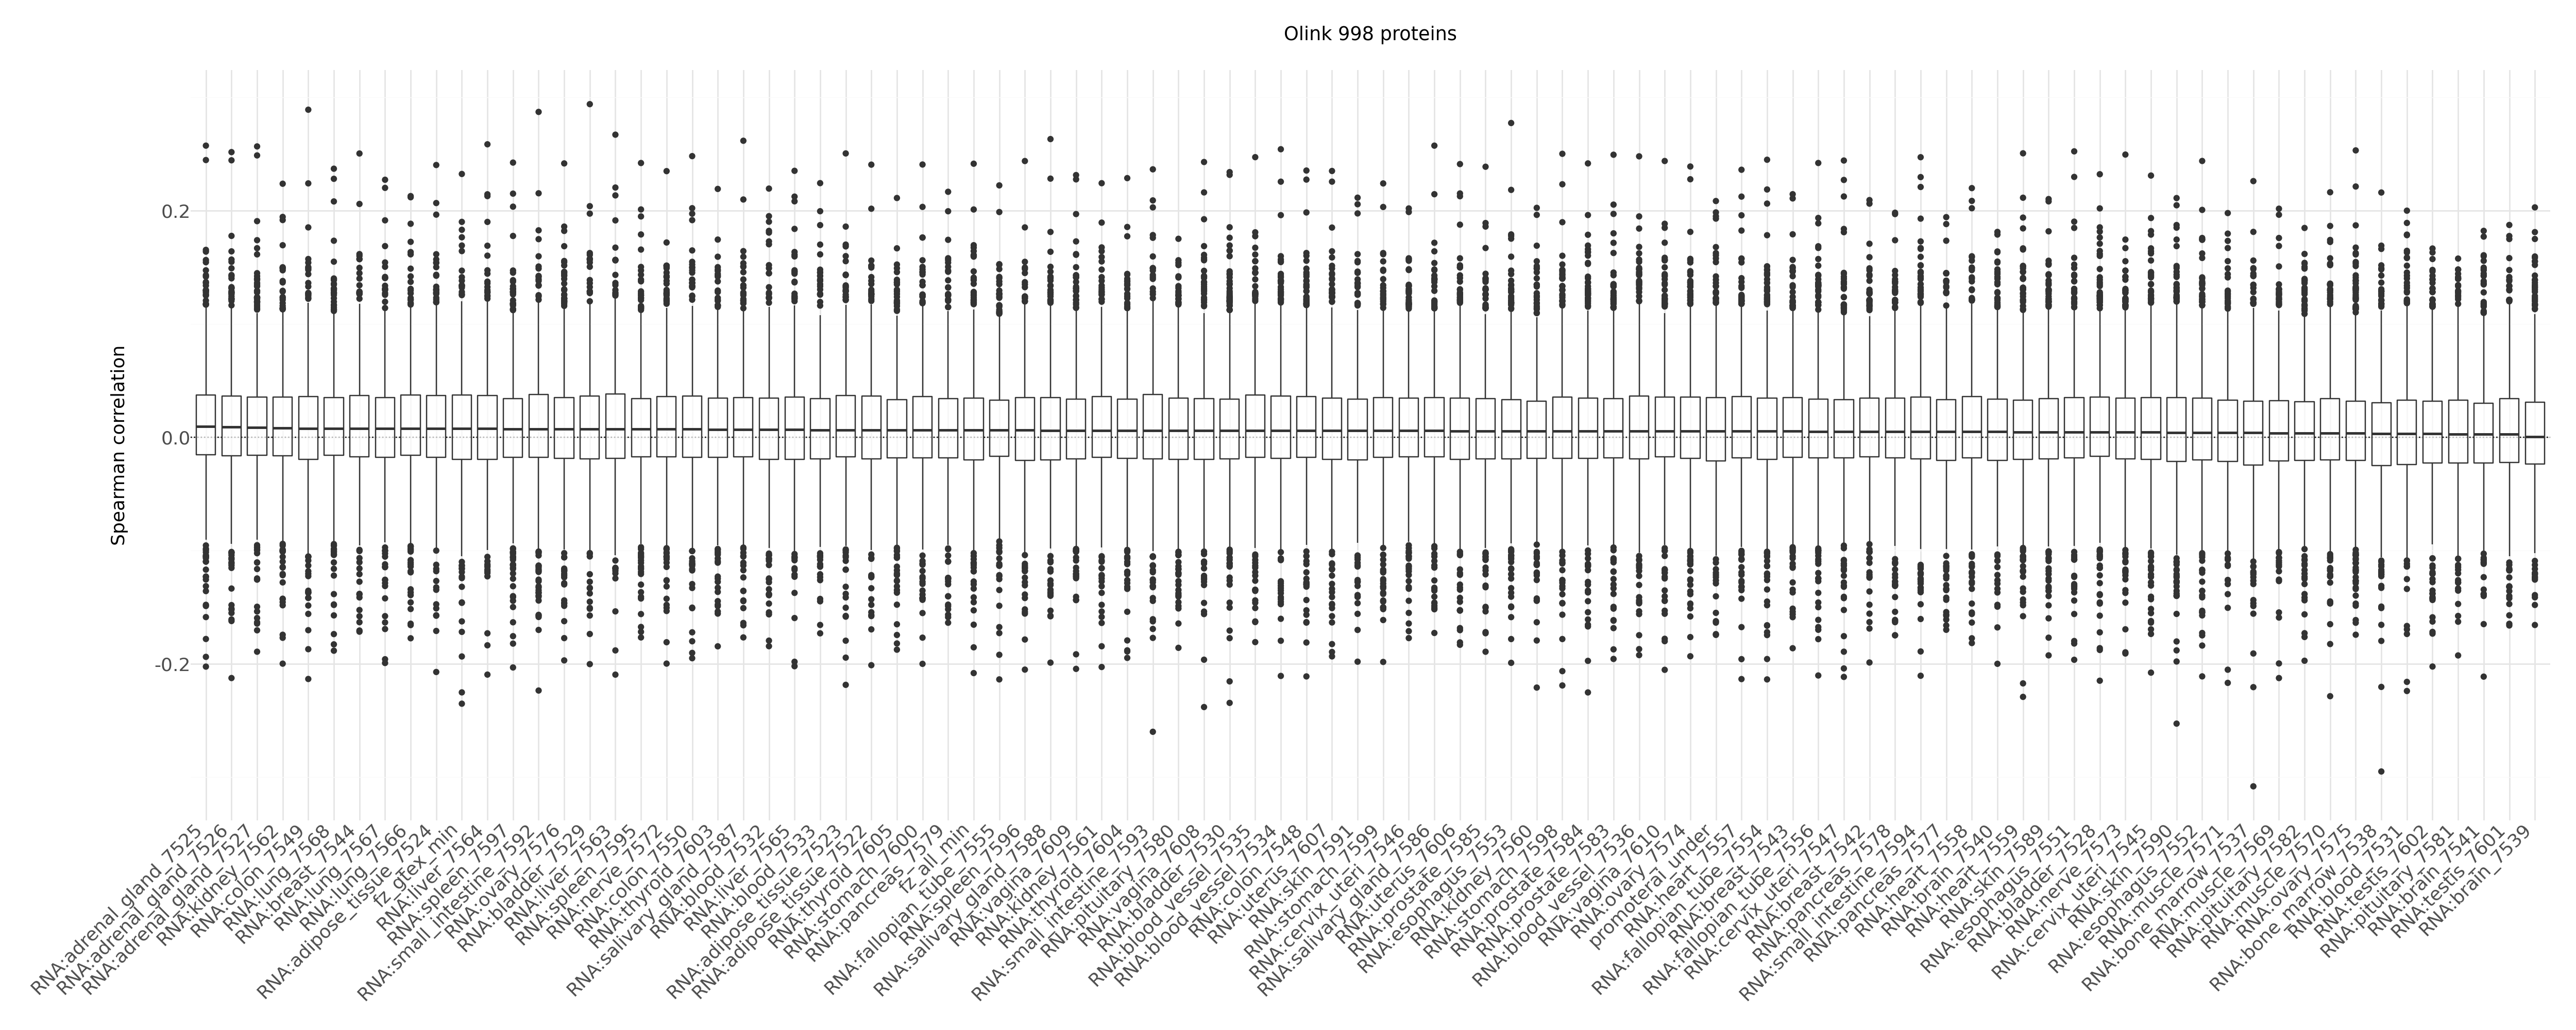

In [11]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=True)
    .select("annotation")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("annotation").cast(pl.Enum(ordered_labels)))

# Plot
(
    ggplot(corr_pl, aes(x="annotation", y=plotting_col))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7, outlier_shape=None)
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pl['region'].unique())} proteins"
    )
    + theme(
        figure_size=(25, 10),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        axis_text_x=element_text(rotation=45, hjust=1),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)